# The evolution operator, and the SU($n$) coefficients

Every notebook so far has asked for probabilities. This one asks for the machinery underneath — the evolution operator itself, and the expansion coefficients the method is built on.

Two reasons to care. If you want to **compose** evolution across segments, or propagate a **density matrix**, or feed an oscillation calculation into something larger, a probability is a dead end and the operator is not. And if you want to see *how* the closed form works rather than take it on trust, the coefficients are where it lives.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## The operator, not the probability

Every `probabilities_*` routine has an `evolution_operator_*` twin taking the same arguments. It returns

$$ U(L) = e^{-i\tilde{H}L} $$

with $\tilde H$ the traceless part of the Hamiltonian, since the trace is only an overall phase.

The probabilities are read off it as $P_{\alpha\beta} = |U_{\beta\alpha}|^2$ — note the index order, which is the one place this is easy to get backwards: the operator is indexed (final, initial), the probabilities (initial, final).

In [2]:
energy = 1.0*GEV
baseline = 1300.0*KM
H = np.asarray(H_VAC_3NU)/energy

U = np.array(oscprob3nu.evolution_operator_3nu(H, baseline))
p = np.array(oscprob3nu.probabilities_3nu(H, baseline))

print("U is %s, complex" % (U.shape,))
print("unitary to        %.2e"
      % np.max(np.abs(U.conj().T @ U - np.eye(3))))

# P[3*alpha + beta] = |U[beta, alpha]|^2
from_U = np.array([abs(U[b, a])**2
                   for a in range(3) for b in range(3)])
print("max |P - |U|^2|   %.2e" % np.max(np.abs(p - from_U)))

U is (3, 3), complex
unitary to        2.22e-15
max |P - |U|^2|   5.55e-17


## The group property, and why slabbing is legitimate

Because $\tilde H$ does not depend on $L$, the operator obeys

$$ U(L_1 + L_2) = U(L_2)\, U(L_1) . $$

This is not a detail — it is the licence for everything the `slabs` and `earth` modules do. A trajectory through varying matter is cut into pieces over which $H$ is taken constant, each piece is solved *exactly*, and the operators are multiplied. The only approximation is the cutting, never the solving.

Note the order: the operator for the **first** segment travelled goes on the **right**.

In [3]:
L1, L2 = 0.4*baseline, 0.6*baseline

U_whole = np.array(oscprob3nu.evolution_operator_3nu(
    H, L1 + L2))
U_1 = np.array(oscprob3nu.evolution_operator_3nu(H, L1))
U_2 = np.array(oscprob3nu.evolution_operator_3nu(H, L2))

print("max |U(L1+L2) - U(L2) U(L1)| = %.2e"
      % np.max(np.abs(U_2 @ U_1 - U_whole)))

# Both segments share one Hamiltonian, so their operators
# commute and the order happens not to matter *here*:
print("with the factors swapped     = %.2e"
      % np.max(np.abs(U_1 @ U_2 - U_whole)))

max |U(L1+L2) - U(L2) U(L1)| = 1.37e-15
with the factors swapped     = 1.27e-15


That second line is not the general case, and it is worth being clear about why it came out the same. Both segments carry the *same* Hamiltonian, so their operators are functions of one matrix and commute. The moment the segments differ — which is what varying matter means — the order matters, and the next section shows it costing you a visibly different answer.

`slabs.evolution_operator_3nu_slabs` does that multiplication for you, in order, given one Hamiltonian per slab:

In [4]:
import earth
import slabs

# Deliberately asymmetric: the order is then observable
widths = np.array([300.0, 600.0, 500.0])*KM
densities = np.array([2.6, 4.5, 9.0])          # g/cm^3

H_seg = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, energy, earth.matter_potential(densities))

U_slabs = np.array(slabs.evolution_operator_3nu_slabs(
    H_seg, widths))

# The same product, written out
U_manual = np.eye(3, dtype=complex)
for k in range(len(widths)):
    U_manual = np.array(oscprob3nu.evolution_operator_3nu(
        H_seg[k], widths[k])) @ U_manual

print("max |slabs - by hand| = %.2e"
      % np.max(np.abs(U_slabs - U_manual)))

# Now traverse the same three slabs in reverse
U_rev = np.array(slabs.evolution_operator_3nu_slabs(
    H_seg[::-1], widths[::-1]))
print("max |forward - reversed| = %.2e" 
      % np.max(np.abs(U_slabs - U_rev)))
print("P_mue forward  = %.6f" % abs(U_slabs[0, 1])**2)
print("P_mue reversed = %.6f" % abs(U_rev[0, 1])**2)

max |slabs - by hand| = 7.73e-16
max |forward - reversed| = 8.01e-02
P_mue forward  = 0.031820
P_mue reversed = 0.047286


Same three slabs, same total length, same mean density — and a different answer, because matrix multiplication does not commute. A neutrino that meets dense matter last is not in the same state as one that met it first. Notebook 08 turns that observation into physics.

## Inside the closed form

The expansion writes the Hamiltonian in the basis of SU(3) generators (the Gell-Mann matrices $\lambda^k$),

$$ H = h_0\mathbb{1} + h_k\lambda^k , $$

and the evolution operator in the same basis,

$$ U_3(L) = u_0\mathbb{1} + i\,u_k\lambda^k . $$

Each of those steps is a public routine, so the method can be inspected rather than assumed.

In [5]:
h = oscprob3nu.hamiltonian_3nu_coefficients(H)
print("h_k : %d real coefficients" % len(h))
print("     ", np.array2string(np.array(h), precision=3))

# Two invariants control the whole result
h2, h3 = oscprob3nu.su3_invariants(h)
print("\n|h|^2      = %.6e   (= Tr(H~^2)/2)" % h2)
print("<h>        = %.6e   (= Tr(H~^3)/2)" % h3)

h_k : 8 real coefficients
      [-1.019e-13 -8.500e-14 -3.458e-13 -1.085e-13 -7.203e-14  5.960e-13
  1.539e-15 -8.287e-14]

|h|^2      = 5.162074e-25   (= Tr(H~^2)/2)
<h>        = 2.134921e-37   (= Tr(H~^3)/2)


The oscillation frequencies are the roots of the characteristic equation, which for SU(3) is a cubic and has a closed trigonometric solution. Up to a sign they are the eigenvalues of the traceless Hamiltonian — the quantities every oscillation phase is built from. The paper writes the characteristic equation for $-\tilde H$, so $\psi_m = -\lambda_m$:

In [6]:
psi = np.sort(np.array(oscprob3nu.psi_roots(h2, h3)))

# The roots are those of the characteristic equation of -H~,
# so they are minus the eigenvalues of H~ itself.
H_traceless = H - np.trace(H)/3.0*np.eye(3)
reference = np.sort(-np.linalg.eigvalsh(H_traceless))

print("psi_m (closed form) :", np.array2string(psi, precision=4))
print("-eigvalsh(H~)       :", np.array2string(reference, precision=4))
print("max difference      : %.2e"
      % np.max(np.abs(psi - reference)))

psi_m (closed form) : [-8.2935e-13  3.9620e-13  4.3315e-13]
-eigvalsh(H~)       : [-8.2935e-13  3.9620e-13  4.3315e-13]
max difference      : 1.21e-27


And the coefficients of the operator, which rebuild it exactly. The Gell-Mann matrices are written out by hand below, and the reason is worth knowing if you go looking for them: `oscprob4nu` exposes `generators_su4()` because at four flavors every quantity it needs is a trace against the generators, whereas `oscprob3nu` contracts the $d$ tensor instead — see `oscprob3nu.tensor_d` — and so never builds the matrices. There is no `generators_su3()` to import.

In [7]:
u = oscprob3nu.evolution_operator_3nu_u_coefficients(
    H, baseline)
print("u_0 and u_1..u_8 : %d complex coefficients" % len(u))

# Rebuild U from them, using the Gell-Mann matrices
lam = np.zeros((8, 3, 3), dtype=complex)
lam[0, 0, 1] = lam[0, 1, 0] = 1.0
lam[1, 0, 1], lam[1, 1, 0] = -1.0j, 1.0j
lam[2, 0, 0], lam[2, 1, 1] = 1.0, -1.0
lam[3, 0, 2] = lam[3, 2, 0] = 1.0
lam[4, 0, 2], lam[4, 2, 0] = -1.0j, 1.0j
lam[5, 1, 2] = lam[5, 2, 1] = 1.0
lam[6, 1, 2], lam[6, 2, 1] = -1.0j, 1.0j
lam[7] = np.diag([1.0, 1.0, -2.0])/np.sqrt(3.0)

U_rebuilt = (u[0]*np.eye(3)
             + 1.0j*np.einsum("k,kij->ij",
                              np.array(u[1:]), lam))
print("max |rebuilt - U| = %.2e"
      % np.max(np.abs(U_rebuilt - U)))

u_0 and u_1..u_8 : 9 complex coefficients
max |rebuilt - U| = 0.00e+00


Seeing them vary is more instructive than one value of each. The $h_k$ are fixed by the Hamiltonian and do not move with distance; the $u_k$ carry the whole $L$ dependence, oscillating at the three frequencies $\psi_m$ set by the latent roots. Every probability in every other notebook is built from these:

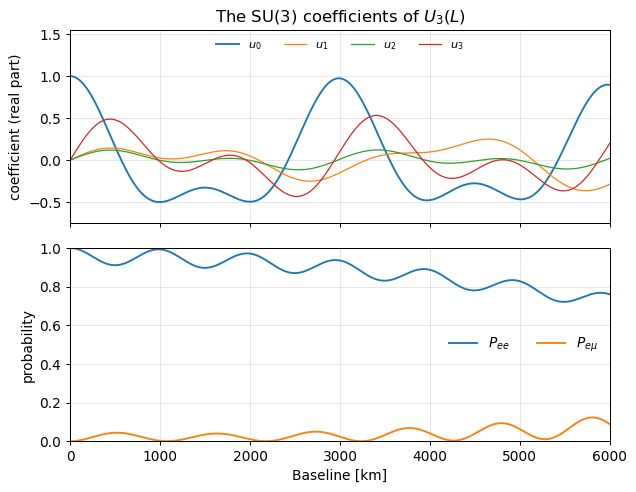

In [8]:
L_km = np.linspace(0.0, 6000.0, 800)
u_of_L = np.array([
    oscprob3nu.evolution_operator_3nu_u_coefficients(
        H, l*KM) for l in L_km])

fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.6),
                         sharex=True)
axes[0].plot(L_km, u_of_L[:, 0].real, label=r"$u_0$")
for k in (1, 2, 3):
    axes[0].plot(L_km, u_of_L[:, k].real, lw=1.0,
                 label=r"$u_%d$" % k)
axes[0].set_ylabel("coefficient (real part)")
axes[0].set_title("The SU(3) coefficients of $U_3(L)$")
# Headroom so the legend clears the u_0 peak
axes[0].set_ylim(-0.75, 1.55)
axes[0].legend(ncol=4, fontsize=9, loc="upper center")

# Rebuilt probabilities, for comparison
p_scan = oscprob3nu.probabilities_3nu(H, L_km*KM)
axes[1].plot(L_km, p_scan[:, 0], label=r"$P_{ee}$")
axes[1].plot(L_km, p_scan[:, 1], label=r"$P_{e\mu}$")
axes[1].set_xlim(L_km[0], L_km[-1])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_xlabel("Baseline [km]")
axes[1].set_ylabel("probability")
axes[1].legend(ncol=2)
fig.tight_layout()
plt.show()

The lower panel is what the other notebooks plot; the upper panel is what it is made of. $u_0$ is the coefficient of the identity, so it stays near one where little has happened, and the $u_k$ grow as flavor content moves between states.

## The same shape at two and four flavors

Nothing above is specific to three. Each module carries the same four entry points — coefficients, invariants, roots, operator — over SU(2), SU(3) and SU(4).

In [9]:
# Two flavors
H2 = np.asarray(
    hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
        gd.S23_NO_BF, gd.D31_NO_BF))/energy
U2 = np.array(oscprob2nu.evolution_operator_2nu(H2, baseline))
print("SU(2): U is %s, unitary to %.1e"
      % (U2.shape,
         np.max(np.abs(U2.conj().T @ U2 - np.eye(2)))))

# Four flavors: fifteen generators, three invariants
lam4 = oscprob4nu.generators_su4()
H4 = np.diag([1.0, 2.0, 3.0, -6.0]).astype(complex)
i2, i3, i4 = oscprob4nu.su4_invariants(H4)
U4 = np.array(oscprob4nu.evolution_operator_4nu(H4, 1.0))
print("SU(4): %d generators, invariants "
      "%.3f %.3f %.3f" % (len(lam4), i2, i3, i4))
print("       U is %s, unitary to %.1e"
      % (U4.shape,
         np.max(np.abs(U4.conj().T @ U4 - np.eye(4)))))

SU(2): U is (2, 2), unitary to 2.2e-16
SU(4): 15 generators, invariants 25.000 -90.000 384.500
       U is (4, 4), unitary to 5.6e-16


## Which one to reach for

| You want | Use |
|---|---|
| A probability | `probabilities_2nu` / `_3nu` / `_4nu` |
| To compose across segments, or a density matrix | `evolution_operator_*` |
| A trajectory through layered matter | `slabs.*`, `earth.*` |
| The oscillation frequencies alone | `psi_roots`, `psi_roots_4nu` |
| To inspect or extend the expansion | `*_coefficients`, `su3_invariants`, `su4_invariants` |

The probability routines are the ones to use by default: they take the shortest path and avoid building the operator when it is not needed. Reach past them when you need what they discard.

---

**Previous:** [Cross-checks with other codes](17_cross_checks.ipynb)  
**Next:** [Animated scenes](19_animations.ipynb) --- four sweeps, as stills, and the reel they came from  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)